# Depth measurements in time (Depth Anything v3)

In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import cv2

In [4]:
from natsort import natsorted

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.colors import ListedColormap
# from mpl_interactions import hyperslicer
# %matplotlib ipympl

In [6]:
from tqdm import tqdm

In [7]:
import os

In [8]:
import torch
from depth_anything_3.api import DepthAnything3

[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70


In [9]:
from PIL import Image

## Model setup

In [10]:
device = torch.device("cuda")

In [11]:
model_name = "depth-anything/DA3-BASE"

In [12]:
model = DepthAnything3.from_pretrained(model_name)

[INFO ] using MLP layer as FFN


In [13]:
model = model.to(device=device)

## IO

In [14]:
background_img_path = "../../../../data/depth_measurements/dormakaba/20251210_085522_7fc184b8/full_image_000005.png"

In [15]:
background_img = Image.open(background_img_path)
background_img = np.array(background_img)
background_img = cv2.rotate(background_img, cv2.ROTATE_90_CLOCKWISE)

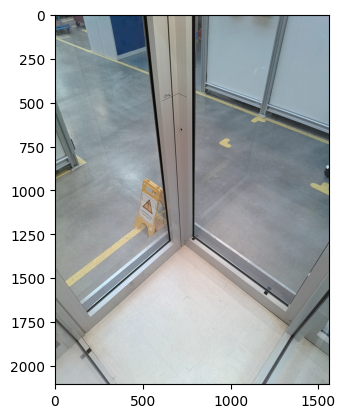

In [16]:
plt.imshow(background_img)

In [17]:
images_path = "../../../../data/depth_measurements/dormakaba/20251210_092401_e8f935ca/rotated/"

In [18]:
images = []
for img_path in natsorted(os.listdir(images_path)):
    img = Image.open(images_path + img_path)
    img = np.array(img)
    # img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    images.append(img)
images.append(background_img)

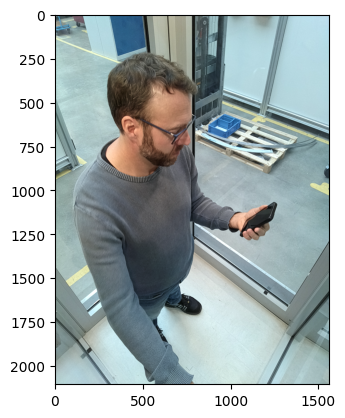

In [19]:
plt.imshow(images[15])
plt.show()

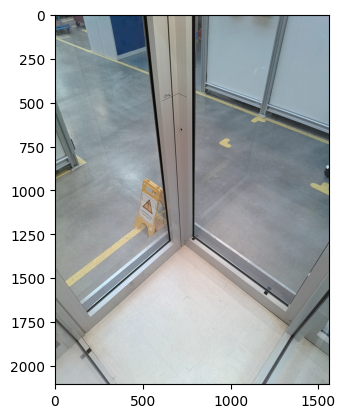

In [20]:
plt.imshow(images[-1])

## Camera setup

- **Camera intrinsics**
    - Effective image resolution (`cam_intriniscs[0, 0]`, `cam_intrinsics[1, 1]`)
        - Sensor resolution is higher but in OAK-D Lite some of the sensor pixels are not used to produce the image but for processing, therefore asking for `cam.requestFullResolutionOutput()` produces images with shape (2104x1560)
    - Center camera offset (`cam_intriniscs[0, 2]`, `cam_intriniscs[1, 2]`)
        - Camera center is offsetted by some pixels    
- **Camera extrinsics**
    - Camera rotation matrix to map 3D point coordinates to camera reference frame. It is computed from Camera attitude (camera pose) with roll, pitch and yaw values.

In [21]:
n_images = len(images)
n_images

52

In [22]:
h, w, c = img.shape
h, w, c

(2104, 1560, 3)

In [23]:
original_cam_intrinsics = np.array([
[1498.00,   0.0,  1040.0],
[   0.0,   1494, 772.0],
[   0.0,    0.0,    1.0]  
])

In [24]:
cam_intrinsics = np.array([
[1494.00,   0.0,  w - 1 - 772.0],
[   0.0,   1498, 1040.0],
[   0.0,    0.0,    1.0]  
])

intrinsics = np.tile(cam_intrinsics, (n_images, 1, 1))

In [25]:
intrinsics.shape

(52, 3, 3)

In [26]:
# w2c_extrinsics = np.array(
#     [[   0.707,   -0.707,    0.   ,    0.   ],
#     [  -0.5  ,   -0.5  ,   -0.707, 1442.498],
#     [   0.5  ,    0.5  ,   -0.707, 1442.498],
#     [   0.   ,    0.   ,    0.   ,    1.   ]]
# )

In [27]:
# w2c_extrinsics.shape

In [28]:
def Rx(alpha):
    ca = np.cos(alpha); sa = np.sin(alpha)
    return np.array([[1,0,0],
                     [0, ca, -sa],
                     [0, sa,  ca]])
 
def Ry(beta):
    cb = np.cos(beta); sb = np.sin(beta)
    return np.array([[ cb, 0, sb],
                     [  0, 1,  0],
                     [-sb, 0, cb]])
 
def Rz(gamma):
    cg = np.cos(gamma); sg = np.sin(gamma)
    return np.array([[cg, -sg, 0],
                     [sg,  cg, 0],
                     [ 0,   0, 1]])

In [29]:
# roll_deg, pitch_deg, yaw_deg = 45, -45, 0
roll_deg, pitch_deg, yaw_deg = 46, -48, 0

r = np.deg2rad(roll_deg); p = np.deg2rad(pitch_deg); y = np.deg2rad(yaw_deg)

#	Rca = Rz(y) @ Ry(p) @ Rx(r)
Rca = Rz(y) @ Rx(r) @ Ry(p)
Rw2c = np.array([[1, 0, 0], [0, 0, -1], [0, 1, 0]])
Cw = np.array([0.0, 0.0, 2040.0]).reshape((3,1))
Rtot = Rca @ Rw2c
print("Matrice Rotazione")
print(Rtot)
tc = -Rtot @ Cw

tmp = np.hstack((Rtot, tc))
Twc = np.vstack((tmp, [0, 0, 0, 1]))
print("Matrice Omogenea")
print(Twc)

Matrice Rotazione
[[ 0.66913061 -0.74314483  0.        ]
 [-0.53457365 -0.48133228 -0.69465837]
 [ 0.51623177  0.46481718 -0.7193398 ]]
Matrice Omogenea
[[ 6.69130606e-01 -7.43144825e-01  0.00000000e+00  0.00000000e+00]
 [-5.34573650e-01 -4.81332277e-01 -6.94658370e-01  1.41710308e+03]
 [ 5.16231773e-01  4.64817177e-01 -7.19339800e-01  1.46745319e+03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [30]:
# w2c_extrinsics = np.array(
#     [[   0.707,   -0.707,    0.   ,    0.   ],
#     [  -0.5  ,   -0.5  ,   -0.707, 1442.498],
#     [   0.5  ,    0.5  ,   -0.707, 1442.498],
#     [   0.   ,    0.   ,    0.   ,    1.   ]]
# )

In [31]:
w2c_extrinsics = Twc

In [32]:
cam_extrinsics = w2c_extrinsics
extrinsics = np.tile(cam_extrinsics, (n_images, 1, 1))

In [33]:
extrinsics.shape

(52, 4, 4)

In [34]:
np.set_printoptions(precision=4, suppress=True)
cam_extrinsics

array([[   0.6691,   -0.7431,    0.    ,    0.    ],
       [  -0.5346,   -0.4813,   -0.6947, 1417.1031],
       [   0.5162,    0.4648,   -0.7193, 1467.4532],
       [   0.    ,    0.    ,    0.    ,    1.    ]])

## Inference

In [35]:
prediction = model.inference(images,
    export_dir="output",
    extrinsics=extrinsics,
    intrinsics=intrinsics,
)

[INFO ] Processed Images Done taking 0.34192919731140137 seconds. Shape:  torch.Size([52, 3, 504, 378])
Extrinsics tensor([[ 6.6913e-01, -7.4314e-01,  0.0000e+00,  0.0000e+00],
        [-5.3457e-01, -4.8133e-01, -6.9466e-01,  1.4171e+03],
        [ 5.1623e-01,  4.6482e-01, -7.1934e-01,  1.4675e+03],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]], device='cuda:0')
Extrinsics dtype: torch.float32
Normalized extrinsics tensor([[ 1.0000e+00, -2.9802e-08,  2.9802e-08,  4.5175e-05],
        [-2.9802e-08,  1.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 2.9802e-08,  0.0000e+00,  1.0000e+00,  1.2207e-03],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]], device='cuda:0')
Normalized extrinsics dtype: torch.float32
[INFO ] Using camera conditions provided by the user
[INFO ] Model Forward Pass Done. Time: 1.5928304195404053 seconds
[INFO ] Conversion to Prediction Done. Time: 0.034384965896606445 seconds
[INFO ] Export Results Done. Time: 0.00037980079650878906 secon

In [36]:
import numpy as np
import cv2

def resize_depth_batch(depth_batch: np.ndarray, orig_size: tuple[int, int]) -> np.ndarray:
    """
    Resize a batch of depth maps to the original image size.

    Args:
        depth_batch: NumPy array of shape (N, H, W)
        orig_size: (width, height) of the original input image

    Returns:
        Resized depth maps as NumPy array of shape (N, H_orig, W_orig)
    """
    N = depth_batch.shape[0]
    orig_w, orig_h = orig_size
    resized_batch = np.zeros((N, orig_h, orig_w), dtype=np.float32)

    for i in range(N):
        resized_batch[i] = cv2.resize(
            depth_batch[i].astype(np.float32),
            (orig_w, orig_h),  # cv2 uses (width, height)
            interpolation=cv2.INTER_LINEAR
        )

    return resized_batch



In [37]:
img.shape

(2104, 1560, 3)

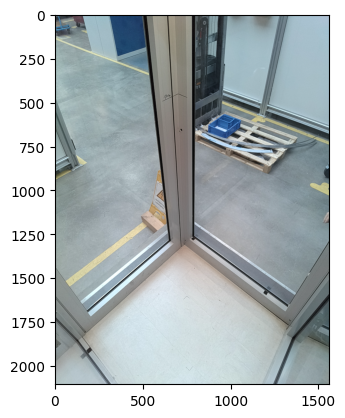

In [38]:
plt.imshow(img)

In [39]:
prediction.depth.shape

(52, 504, 378)

In [40]:
resized_depth = resize_depth_batch(prediction.depth, orig_size=(img.shape[1], img.shape[0]))

In [41]:
resized_depth.shape

(52, 2104, 1560)

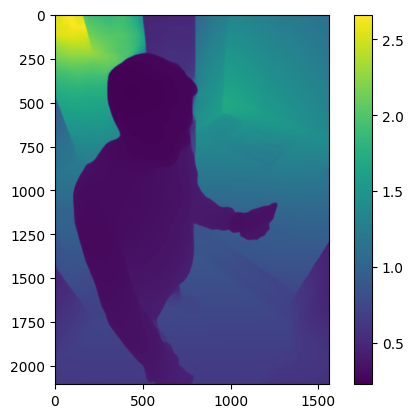

In [42]:
plt.imshow(resized_depth[15])
plt.colorbar()
plt.show()

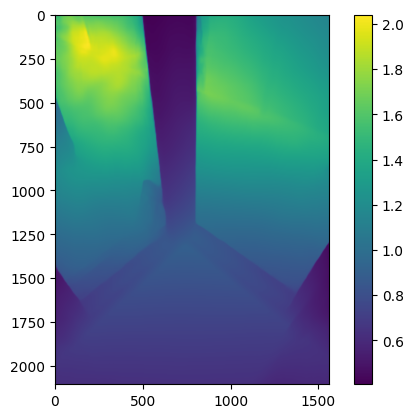

In [43]:
plt.imshow(resized_depth[-1])
plt.colorbar()
plt.show()

In [44]:
h, w, c = img.shape

In [45]:
point_ids = ["P0", "C0", "P1", "P2", "P3", "PE"]
x_img =  np.array([w//2, 0, 1273, 730, 205, 700])
y_img =  np.array([h//2, 0, 1774, 1327, 1831, 457])

In [46]:
data = {
    "point_id": point_ids,
    "x_world": [0, 0, 1040, 1040, 0, 1040],
    "y_world": [0, 0, 0, 1040, 1040, 1040],
    "z_world": [0, 2030, 0, 0, 0, 1400],
    "u": x_img,
    "v": y_img,
}

In [47]:
df = pd.DataFrame(data)

In [48]:
idx = 15
depth = resized_depth[idx]

In [49]:
# Calculate distance from C0 (skip C0 itself)
C0_coords = np.array([0, 0, 2030])
df["distance"] = df.apply(
    lambda row: np.linalg.norm(np.array([row["x_world"], row["y_world"], row["z_world"]]) - C0_coords),
    axis=1
)

In [50]:
df["depth_level"] = df.apply(
    lambda row: depth[int(row["v"]), int(row["u"])]
                if not pd.isna(row["u"]) and not pd.isna(row["v"]) else np.nan,
    axis=1
)

In [51]:
# Rank by distance (ascending) and depth_level (ascending)
df['distance_rank'] = df['distance'].rank(method='min', ascending=True)
df['depth_rank'] = df['depth_level'].rank(method='min', ascending=True)
df['rank_match'] = df.apply(lambda row: True if row['distance_rank'] == row['depth_rank'] else False, axis=1)
df_sorted = df.sort_values(by=['distance_rank', 'depth_rank']).reset_index(drop=True)

In [52]:
df_sorted

,point_id,x_world,y_world,z_world,u,v,distance,depth_level,distance_rank,depth_rank,rank_match
0,C0,0,0,2030,0,0,0.000000,2.515274,1.0,6.0,False
1,PE,1040,1040,1400,700,457,1600.031250,0.256047,2.0,1.0,False
2,P0,0,0,0,780,1052,2030.000000,0.398417,3.0,3.0,True
3,P3,0,1040,0,205,1831,2280.898946,0.707517,4.0,4.0,True
4,P1,1040,0,0,1273,1774,2280.898946,0.722500,4.0,5.0,False
5,P2,1040,1040,0,730,1327,2506.810723,0.388516,6.0,2.0,False


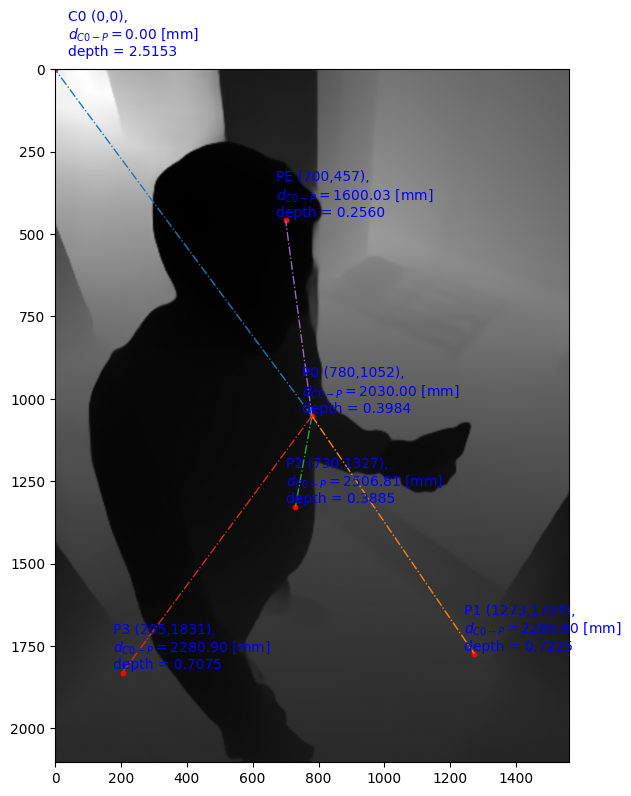

In [53]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(depth, cmap="grey")
ax.scatter(df["u"], df["v"], marker='o', s=10, c="red")

# Plot lines from P0 (assume P0 is first row) to other points
x0, y0 = df.loc[0, "u"], df.loc[0, "v"]

for idx, (point_id, x, y, dist, depth_value) in enumerate(zip(df["point_id"], df["u"], df["v"], df["distance"], df["depth_level"])):
    # Skip line for P0 itself
    if idx != 0:
        ax.plot([x0, x], [y0, y], '-.', linewidth=1)
        
    # Offset label for C0 to avoid overlap
    if idx == 1:  # C0
        label_x = x + 40
        label_y = y - 40
    else:
        label_x = x - 30
        label_y = y - 10
    
    ax.text(label_x, label_y, f"{point_id} ({x},{y}),\n$d_{{{{C0}}-P}} = {dist:.2f}$ [mm]\ndepth = {depth_value:.4f}", color='b')


plt.show()

## Red zone

In [54]:
df_sorted

,point_id,x_world,y_world,z_world,u,v,distance,depth_level,distance_rank,depth_rank,rank_match
0,C0,0,0,2030,0,0,0.000000,2.515274,1.0,6.0,False
1,PE,1040,1040,1400,700,457,1600.031250,0.256047,2.0,1.0,False
2,P0,0,0,0,780,1052,2030.000000,0.398417,3.0,3.0,True
3,P3,0,1040,0,205,1831,2280.898946,0.707517,4.0,4.0,True
4,P1,1040,0,0,1273,1774,2280.898946,0.722500,4.0,5.0,False
5,P2,1040,1040,0,730,1327,2506.810723,0.388516,6.0,2.0,False


In [55]:
def project_points_world_to_image(points_world, w2c, K):
    """
    points_world : (N, 3) array
    w2c          : (4, 4) world-to-camera matrix
    K            : (3, 3) intrinsic matrix
    returns      : (N, 2) pixel coordinates
    """

    # Convert to homogeneous (N, 4)
    ones = np.ones((points_world.shape[0], 1))
    points_h = np.hstack([points_world, ones])      # (N,4)

    # Camera coordinates: Pc = w2c @ Pw
    points_cam = (w2c @ points_h.T).T               # (N,4)

    # Extract X, Y, Z
    Xc = points_cam[:, 0]
    Yc = points_cam[:, 1]
    Zc = points_cam[:, 2]

    # Avoid division by zero
    Zc[Zc == 0] = 1e-6

    # Normalize
    x = Xc / Zc
    y = Yc / Zc

    
    # Apply intrinsics
    u = K[0,0] * x + K[0,2]
    v = K[1,1] * y + K[1,2]
    
    # Stack into (N, 2)
    return np.vstack([u, v]).T

In [56]:
df_ref = df[~df["point_id"].isin(["C0", "P0"])]
df_ref

,point_id,x_world,y_world,z_world,u,v,distance,depth_level,distance_rank,depth_rank,rank_match
2,P1,1040,0,0,1273,1774,2280.898946,0.722500,4.0,5.0,False
3,P2,1040,1040,0,730,1327,2506.810723,0.388516,6.0,2.0,False
4,P3,0,1040,0,205,1831,2280.898946,0.707517,4.0,4.0,True
5,PE,1040,1040,1400,700,457,1600.031250,0.256047,2.0,1.0,False


In [57]:
ref_points_world = df_ref.loc[:, "x_world":"z_world"]
ref_points_world

,x_world,y_world,z_world
2,1040,0,0
3,1040,1040,0
4,0,1040,0
5,1040,1040,1400


In [58]:
ref_points_world.shape

(4, 3)

In [59]:
np.array(ref_points_world)

array([[1040,    0,    0],
       [1040, 1040,    0],
       [   0, 1040,    0],
       [1040, 1040, 1400]])

In [60]:
np.set_printoptions(precision=3, suppress=True)

In [61]:
# compute projections
projected_points = project_points_world_to_image(ref_points_world, w2c_extrinsics, cam_intrinsics)
df_ref["u_from_world"] = projected_points[:, 0].astype(int)
df_ref["v_from_world"] = projected_points[:, 1].astype(int)

In [62]:
df_ref

,point_id,x_world,y_world,z_world,u,v,distance,depth_level,distance_rank,depth_rank,rank_match,u_from_world,v_from_world
2,P1,1040,0,0,1273,1774,2280.898946,0.722500,4.0,5.0,False,1305,1683
3,P2,1040,1040,0,730,1327,2506.810723,0.388516,6.0,2.0,False,740,1257
4,P3,0,1040,0,205,1831,2280.898946,0.707517,4.0,4.0,True,195,1743
5,PE,1040,1040,1400,700,457,1600.031250,0.256047,2.0,1.0,False,709,420


In [63]:
fx = cam_intrinsics[0, 0]
fy = cam_intrinsics[1, 1]

In [64]:
# compute projection error
df_ref["u_error"] = df_ref["u"] - df_ref["u_from_world"]
df_ref["v_error"] = df_ref["v"] - df_ref["v_from_world"]
df_ref["u_error_mm"] = (df_ref["distance"] / fx) * df_ref["u_error"]
df_ref["v_error_mm"] = (df_ref["distance"] / fy) * df_ref["v_error"]

In [65]:
df_ref["u_error_mm"].describe()

count     4.000000
mean    -15.001366
std      26.420555
min     -48.854596
25%     -24.798040
50%     -13.208965
75%      -3.412292
max      15.267061
Name: u_error_mm, dtype: float64

In [66]:
df_ref["v_error_mm"].describe()

count      4.000000
mean     107.302874
std       46.117686
min       39.520131
25%       97.735549
50%      125.566041
75%      135.133365
max      138.559282
Name: v_error_mm, dtype: float64

In [67]:
aabb_x_min = 0
aabb_x_max = 1040
aabb_y_min = 0
aabb_y_max = 1040
aabb_z_min = 0
aabb_z_max = 2000

In [68]:
aabb_world = np.array([
    [aabb_x_min, aabb_y_min, aabb_z_min],
    [aabb_x_max, aabb_y_min, aabb_z_min], 
    [aabb_x_min, aabb_y_max, aabb_z_min],
    [aabb_x_max, aabb_y_max, aabb_z_min], 
    
    [aabb_x_min, aabb_y_min, aabb_z_max],
    [aabb_x_max, aabb_y_min, aabb_z_max], 
    [aabb_x_min, aabb_y_max, aabb_z_max],
    [aabb_x_max, aabb_y_max, aabb_z_max], 
])

In [69]:
aabb_world

array([[   0,    0,    0],
       [1040,    0,    0],
       [   0, 1040,    0],
       [1040, 1040,    0],
       [   0,    0, 2000],
       [1040,    0, 2000],
       [   0, 1040, 2000],
       [1040, 1040, 2000]])

In [70]:
aabb_world.shape

(8, 3)

In [71]:
aabb_img = project_points_world_to_image(aabb_world, w2c_extrinsics, cam_intrinsics)

In [72]:
u_aabb = aabb_img[:, 0]
v_aabb = aabb_img[:, 1]

In [73]:
faces = [
    [0, 1, 3, 2],  # bottom  (z = 0)
    [4, 5, 7, 6],  # top     (z = 2000)

    [0, 1, 5, 4],  # front  (y = 0)
    [2, 3, 7, 6],  # back   (y = 1040)

    [0, 2, 6, 4],  # left   (x = 0)
    [1, 3, 7, 5],  # right  (x = 1040)
]

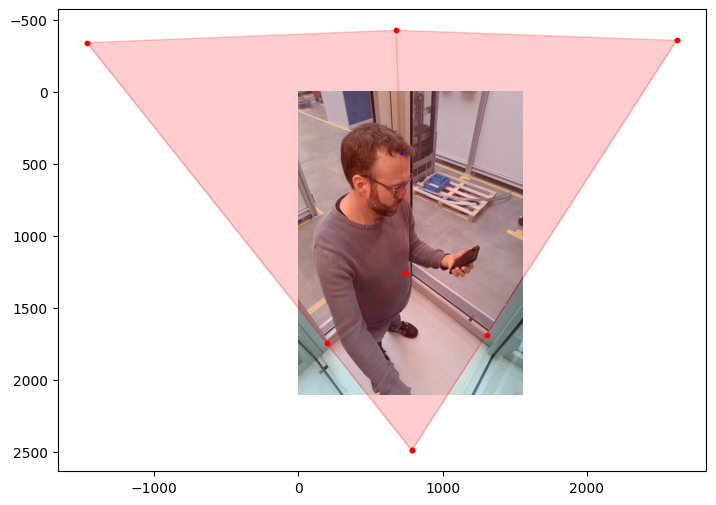

In [74]:
idx = 15
fig, ax = plt.subplots(figsize=(12, 6))

# img
ax.imshow(images[idx])

# reference points
ax.scatter(df_ref["u_from_world"], df_ref["v_from_world"], s=2, c="blue")

# axis aligned bbox vertices
ax.scatter(u_aabb, v_aabb, s=10, c="red")

for f in faces:
    poly = Polygon(aabb_img[f], closed=True, edgecolor='red', facecolor='red', alpha=0.1)
    ax.add_patch(poly)

plt.show()

In [75]:
df

,point_id,x_world,y_world,z_world,u,v,distance,depth_level,distance_rank,depth_rank,rank_match
0,P0,0,0,0,780,1052,2030.000000,0.398417,3.0,3.0,True
1,C0,0,0,2030,0,0,0.000000,2.515274,1.0,6.0,False
2,P1,1040,0,0,1273,1774,2280.898946,0.722500,4.0,5.0,False
3,P2,1040,1040,0,730,1327,2506.810723,0.388516,6.0,2.0,False
4,P3,0,1040,0,205,1831,2280.898946,0.707517,4.0,4.0,True
5,PE,1040,1040,1400,700,457,1600.031250,0.256047,2.0,1.0,False


In [76]:
# # compute scale nearby the center of the image frame
# depth_to_metric_scale = 2280.898946 / 0.817487	
# depth_to_metric_scale

In [77]:
background_depth = resized_depth[-1]

In [78]:
background_depth

array([[1.526, 1.526, 1.523, ..., 1.124, 1.123, 1.123],
       [1.526, 1.526, 1.523, ..., 1.124, 1.123, 1.123],
       [1.525, 1.525, 1.522, ..., 1.124, 1.123, 1.123],
       ...,
       [0.64 , 0.64 , 0.639, ..., 0.604, 0.602, 0.602],
       [0.641, 0.641, 0.64 , ..., 0.604, 0.602, 0.602],
       [0.641, 0.641, 0.64 , ..., 0.604, 0.602, 0.602]], dtype=float32)

In [79]:
def project_points_world_to_camera(points_world, w2c):
    """
    points_world : (N, 3) array
    w2c          : (4, 4) world-to-camera matrix
    returns      : (N, 3) camera coordinates
    """

    # Convert to homogeneous (N, 4)
    ones = np.ones((points_world.shape[0], 1))
    points_h = np.hstack([points_world, ones])      # (N,4)

    # Camera coordinates: Pc = w2c @ Pw
    points_cam = (w2c @ points_h.T).T               # (N,4)

    # Extract X, Y, Z
    Xc = points_cam[:, 0]
    Yc = points_cam[:, 1]
    Zc = points_cam[:, 2]

    return np.array([Xc, Yc, Zc])

In [80]:
Xc, Yc, Zc = project_points_world_to_camera(np.array([1040,	1040,	0]).reshape(1, 3), w2c_extrinsics)

In [81]:
# compute scale nearby the center of the image frame on background img
depth_to_metric_scale = float(Zc) / background_depth[730, 1327]
depth_to_metric_scale

1717.7463771414123

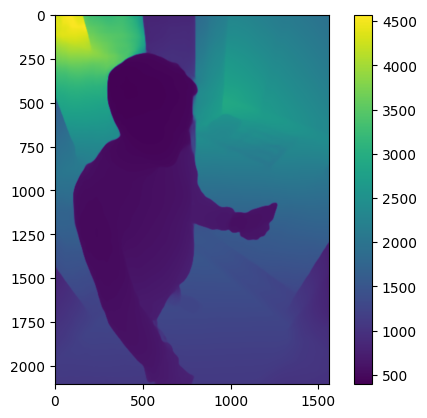

In [82]:
scaled_depth = resized_depth[idx] * float(depth_to_metric_scale)
plt.imshow(scaled_depth)
plt.colorbar()

## Red zone check

In [83]:
h, w = depth.shape

In [84]:
# Create pixel grid
u_grid = np.arange(w)
v_grid = np.arange(h)
uu, vv = np.meshgrid(u_grid, v_grid) 

In [85]:
def project_points_image_to_world(u, v, depth, K, w2c):
    """
    u, v      : pixel coordinates (can be arrays of shape (N,))
    depth     : depth in same units as world (meters or mm) at each pixel
    K         : 3x3 camera intrinsics
    w2c       : 4x4 world-to-camera matrix
    returns   : Nx3 world coordinates
    """
    # Convert depth to float array
    depth = np.asarray(depth, dtype=float)
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    
    fx = K[0,0]
    fy = K[1,1]
    cx = K[0,2]
    cy = K[1,2]
    
    # Back-project to camera coordinates
    Xc = (u - cx) * depth / fx
    Yc = (v - cy) * depth / fy
    Zc = depth
    
    # Stack homogeneous coordinates
    points_cam_h = np.stack([Xc, Yc, Zc, np.ones_like(Zc)], axis=-1)  # Nx4
    
    # Invert w2c to get camera-to-world
    c2w = np.linalg.inv(w2c)
    
    # World coordinates
    points_world_h = (c2w @ points_cam_h.T).T  # Nx4
    points_world = points_world_h[:, :3]
    
    return points_world

In [86]:
depths_points_world = []
for depth_map in tqdm(resized_depth.copy()):
    depth_map *= float(depth_to_metric_scale)
    depth_points_world = project_points_image_to_world(
        uu.ravel(), vv.ravel(), depth_map.ravel(),
        K=cam_intrinsics, w2c=w2c_extrinsics
    )
    depth_points_world = depth_points_world.reshape(h, w, 3)
    depths_points_world.append(depth_points_world)
depths_points_world = np.array(depths_points_world)

100%|██████████████████████████████████████████████████████████████████████████████| 52/52 [00:07<00:00,  7.03it/s]


In [87]:
aabb_world.min(axis=0)

array([0, 0, 0])

In [88]:
aabb_world.max(axis=0)

array([1040, 1040, 2000])

In [89]:
def points_inside_aabb(points_world, aabb):
    """
    points_world : (..., 3) array of 3D points in world coordinates
    aabb         : (8, 3) array of AABB corner points in world coordinates
    returns      : boolean mask of same shape as points_world[...,0], True if inside
    """
    # Compute min/max along each axis
    mins = aabb.min(axis=0)
    maxs = aabb.max(axis=0)
    
    # Vectorized check
    inside_mask = np.all((points_world >= mins) & (points_world <= maxs), axis=-1)
    
    return inside_mask

In [90]:
inside_masks = []
for depth_points_world in tqdm(depths_points_world):
    inside_mask = points_inside_aabb(depth_points_world, aabb_world)
    inside_masks.append(inside_mask)

100%|██████████████████████████████████████████████████████████████████████████████| 52/52 [00:03<00:00, 14.01it/s]


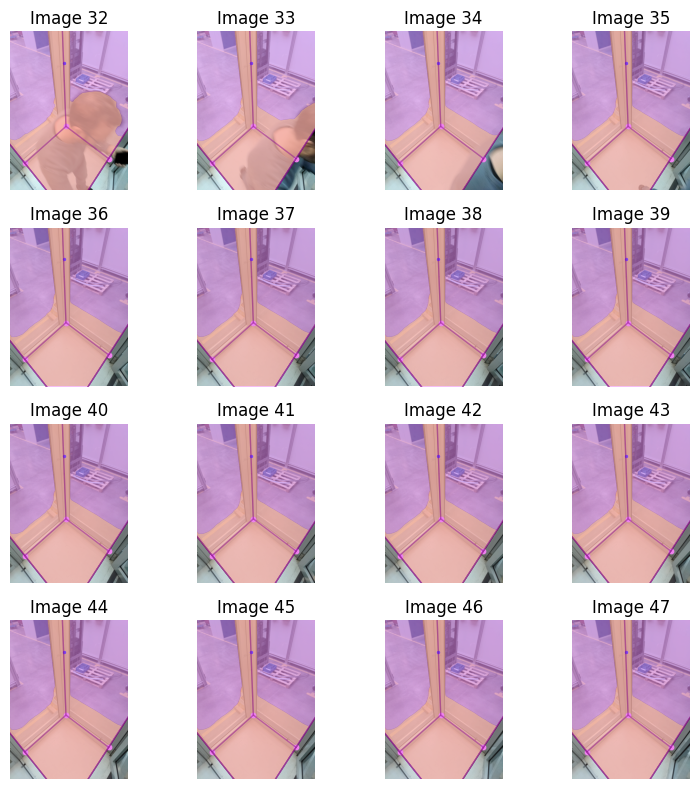

In [91]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

yellow_cmap = ListedColormap(['yellow'])

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
axes = axes.ravel()
indices = range(32, 48)

for i, ax in zip(indices, axes):

    img = images[i]
    inside_mask = inside_masks[i]

    # show the image
    ax.imshow(img)

    # reference points
    ax.scatter(df_ref["u_from_world"], df_ref["v_from_world"], s=2, c="blue")

    # axis-aligned bbox vertices
    ax.scatter(u_aabb, v_aabb, s=10, c="violet")

    # draw faces
    for f in faces:
        poly = Polygon(aabb_img[f], closed=True,
                       edgecolor='purple', facecolor='violet', alpha=0.3)
        ax.add_patch(poly)

    # overlay inside_mask only where True
    masked = np.ma.masked_where(~inside_mask, inside_mask)
    ax.imshow(masked, alpha=0.5, cmap=yellow_cmap)

    ax.set_title(f"Image {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()


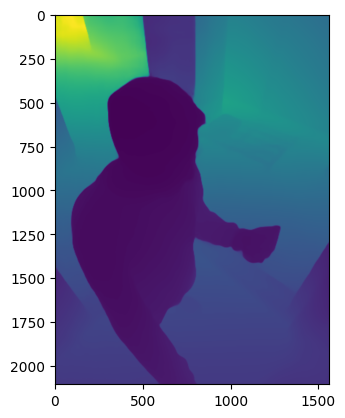

In [97]:
plt.imshow(resized_depth[23])

In [98]:
resized_depth[23, 1000, 500]

0.25746787